# Session 5: CNN on MNIST and YOLOv8

This notebook contains structured tasks for building a CNN on MNIST and experimenting with Ultralytics YOLOv8 (pretrained inference and a short training example).

**Instructions:**
- Complete all tasks directly in this notebook.
- Keep your code clear and well-commented.
- Use `%matplotlib inline` for visualizations.
- If you need to install packages (e.g., `ultralytics`), use `%pip` in a cell.
- When using external datasets, do NOT upload them to GitHub.

### ***DO NOT UPLOAD LARGE DATASETS OR MODEL WEIGHTS TO GITHUB***
<hr>

## Task 1: Convolutional Neural Network on MNIST — Build, Train, Evaluate, Visualize
Train a simple CNN on the MNIST handwritten digits dataset. After training, generate predictions on the test set, compare them to ground truth labels, and visualize a few results.

**Why this matters:**
- MNIST is a classic entry point for image classification and CNNs.
- You will practice the full workflow: data loading, model definition, training, evaluation, and visualization.

**Steps:**
- Load MNIST with appropriate transforms (normalize).
- Define a small CNN (Conv → ReLU → Pool → FC).
- Train for a few epochs (2–3 for demo).
- Evaluate on the test set and compute accuracy.
- Visualize several test images with predicted and true labels.

**Hint:** Use `torchvision.datasets.MNIST`, `DataLoader`, `nn.Conv2d`, `nn.ReLU`, `nn.MaxPool2d`, and `nn.CrossEntropyLoss`.

In [1]:
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import random

# Reproducibility
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
%matplotlib inline


In [2]:
# Transform: Convert to tensor and normalize to mean=0.1307, std=0.3081
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=1000, shuffle=False)


100%|██████████| 9.91M/9.91M [00:00<00:00, 18.5MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 505kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.59MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.99MB/s]


In [3]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(1, 10, kernel_size=5)
        self.pool = nn.MaxPool2d(2)
        self.conv2 = nn.Conv2d(10, 20, kernel_size=5)
        self.fc1 = nn.Linear(320, 50)
        self.fc2 = nn.Linear(50, 10)

    def forward(self, x):
        x = self.pool(torch.relu(self.conv1(x)))  # [batch, 10, 12, 12]
        x = self.pool(torch.relu(self.conv2(x)))  # [batch, 20, 4, 4]
        x = x.view(-1, 320)                       # Flatten
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

model = SimpleCNN().to(device)


In [4]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
for epoch in range(3):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    print(f"Epoch {epoch+1}: Loss={running_loss:.3f}, Accuracy={100*correct/total:.2f}%")


Epoch 1: Loss=215.792, Accuracy=93.21%
Epoch 2: Loss=60.538, Accuracy=98.03%
Epoch 3: Loss=44.891, Accuracy=98.48%


In [5]:
model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"Test Accuracy: {100*correct/total:.2f}%")


Test Accuracy: 98.51%


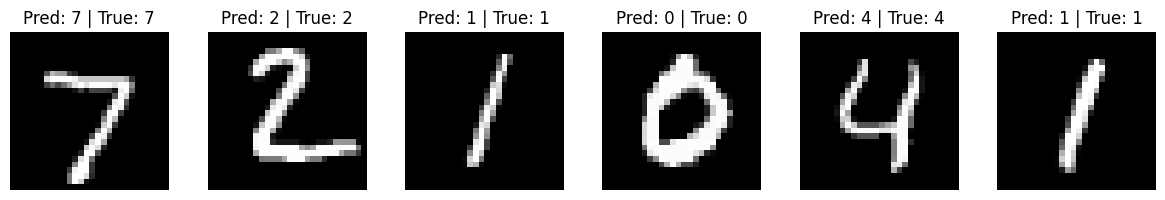

In [6]:
def visualize_predictions(model, loader, device):
    model.eval()
    images, labels = next(iter(loader))
    images, labels = images.to(device), labels.to(device)
    outputs = model(images)
    _, preds = torch.max(outputs, 1)

    fig, axes = plt.subplots(1, 6, figsize=(12, 2))
    for i in range(6):
        axes[i].imshow(images[i].cpu().squeeze(), cmap='gray')
        axes[i].set_title(f"Pred: {preds[i].item()} | True: {labels[i].item()}")
        axes[i].axis('off')
    plt.tight_layout()
    plt.show()

visualize_predictions(model, test_loader, device)


## Task 2: YOLOv8 Pretrained Predictions (No Training)
Use a pretrained YOLOv8 model to run inference on any image of your choice and visualize detections.

**Why this matters:**
- Demonstrates transfer learning and using pretrained models for object detection.
- Learn how to quickly test a detector on real images.

**Steps:**
- Install `ultralytics` if not available.
- Load a YOLOv8 model (e.g., `yolov8n.pt`).
- Run predictions on an image path.
- Visualize the detections (boxes, labels, confidences).

**Hint:** Use `from ultralytics import YOLO`, `YOLO('yolov8n.pt')`, and `model.predict(source=...)`.

In [8]:

%pip install ultralytics
from ultralytics import YOLO


model = YOLO('yolov8n.pt')


image_path = '/content/owel.jpg'

# Run prediction
results = model.predict(source=image_path, save=False)


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.

image 1/1 /content/owel.jpg: 320x640 1 bird, 1 dog, 162.9ms
Speed: 13.0ms preprocess, 162.9ms inference, 24.5ms postprocess per image at shape (1, 3, 320, 640)


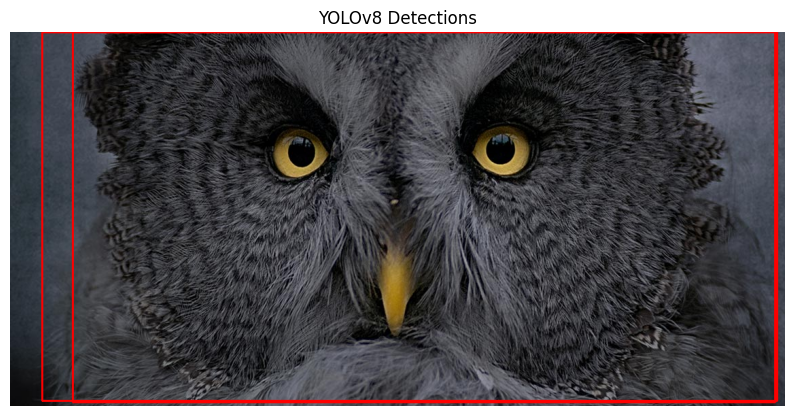

In [9]:
import cv2
import matplotlib.pyplot as plt

# Load image with OpenCV (BGR format)
img_bgr = cv2.imread(image_path)
img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)

# Draw boxes from results
for r in results:
    for box in r.boxes:
        x1, y1, x2, y2 = map(int, box.xyxy[0])
        cls = int(box.cls[0])
        conf = float(box.conf[0])
        label = model.names[cls]

        # Draw rectangle and label
        cv2.rectangle(img_rgb, (x1, y1), (x2, y2), (255, 0, 0), 2)
        cv2.putText(img_rgb, f'{label} {conf:.2f}', (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 0, 0), 2)

# Show image
plt.figure(figsize=(10, 6))
plt.imshow(img_rgb)
plt.axis('off')
plt.title('YOLOv8 Detections')
plt.show()


## Task 3: YOLOv8 Training Example (Small Demo)
Choose any small dataset (e.g., from Roboflow or Kaggle) and train a YOLOv8 model for a few epochs (e.g., 3) as a demonstration. Then run predictions with the trained model.

**Why this matters:**
- Understand the end-to-end YOLO training pipeline.
- See how dataset configuration (classes, paths) connects to training code.

**Steps:**
- Prepare your dataset directory and a `data.yaml` describing train/val paths and class names.
- Train a small model (e.g., `yolov8n.pt`) for ~3 epochs.
- Run predictions on a few sample images.
- Reflect: Are the predictions what you expected? Why or why not?

**Notes:**
- Do NOT upload datasets to GitHub. Keep them locally or use a data hosting service.
- Training for 3 epochs is just for demonstration; try longer training later.
- If you can't use GPU, small images and fewer epochs help.
- If you can't use GPU, you can train your models on Kaggle or Google Colab in the future for free access to GPUs on their servers

In [ ]:
# TODO: Provide path to your YOLOv8 data.yaml
# - Ensure train/val image directories and class names are correct

In [ ]:
# TODO: Train YOLOv8 for a few epochs (e.g., 3)
# - Save the path to best weights (runs/detect/train*/weights/best.pt)

In [ ]:
# TODO: Run predictions with the trained YOLO model and visualize
# - Pick one or more images and display bounding boxes/labels

### Reflection
- Are the predictions what you expected?
- If performance is weak, why? (data size/quality, epochs, augmentations, etc.)
- What would you adjust for a more serious training run?
- What other arguments can you use for the training function.